[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Quantlets/Ch_15/SFM_ch15_seminar/SFM_ch15_seminar.ipynb)

# Statistics of Financial Markets — Seminar 15: Systemic risk

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- This seminar comes before Lecture 15: the slides "What You Need for Today" give every definition used here.
- Part A: computations on paper, checked in code. Part B: real data with inference and an interpretation question. Part C: an open question and an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> Quantlet `SFM_ch15_seminar`: student version of the Seminar 15 notebook. Solved exercises (A1, A3, A5, B1, B3, B5) are shown with code and output; the proposed exercises (A2, A4, A6, B2, B4, B6, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_15'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Seminar functions

- Data: bank prices, returns on common days, equal-weighted bank portfolios.
- Measures: quantile regression, CoVaR and Delta-CoVaR, moving-block bootstrap, MES, LRMES, SRISK, the Forbes–Rigobon correction, VAR and connectedness.
- Helpers for Part A and Part B: CoVaR from a regression, the inputs of A1 and A2, the table of March 2020, MES by hand, SRISK of one and of several banks, the measures of a region, the Fisher z test, a contagion test, MES before a crisis against the losses in it.

In [ ]:
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from scipy.special import gammaln
START, END = '2005-01-01', '2026-09-18'
BANKS = {'JPM': ('JPM.US', 'JPMorgan Chase', 'US'), 'BAC': ('BAC.US', 'Bank of America', 'US'), 'C': ('C.US', 'Citigroup', 'US'), 'GS': ('GS.US', 'Goldman Sachs', 'US'), 'MS': ('MS.US', 'Morgan Stanley', 'US'), 'WFC': ('WFC.US', 'Wells Fargo', 'US'), 'DBK': ('DBK.XETRA', 'Deutsche Bank', 'EU'), 'BNP': ('BNP.PA', 'BNP Paribas', 'EU'), 'SAN': ('SAN.MC', 'Santander', 'EU'), 'INGA': ('INGA.AS', 'ING', 'EU'), 'HSBA': ('HSBA.LSE', 'HSBC', 'EU'), 'TLV': ('TLV.RO', 'Banca Transilvania', 'RO'), 'BRD': ('BRD.RO', 'BRD', 'RO')}
REGIONS = {'US': ['JPM', 'BAC', 'C', 'GS', 'MS', 'WFC'], 'EU': ['DBK', 'BNP', 'SAN', 'INGA', 'HSBA'], 'RO': ['TLV', 'BRD']}
ALL = ['JPM', 'BAC', 'C', 'GS', 'MS', 'WFC', 'DBK', 'BNP', 'SAN', 'INGA', 'HSBA', 'TLV', 'BRD']
INTL = ['JPM', 'BAC', 'C', 'GS', 'MS', 'WFC', 'DBK', 'BNP', 'SAN', 'INGA', 'HSBA']
REGION_START = {'US': '2005-01-01', 'EU': '2005-01-01', 'RO': '2010-01-01'}
INDEX = {'US': 'sp500', 'EU': 'stoxx50', 'RO': 'bet'}
INDEX_NAME = {'sp500': 'S&P 500', 'stoxx50': 'Euro Stoxx 50', 'bet': 'BET'}
REG_COL = {'US': '#1A3A6E', 'EU': '#CD0000', 'RO': '#2E7D32'}
REG_LAB = {'US': 'US banks', 'EU': 'European banks', 'RO': 'Romanian banks (TLV, BRD, since 2010)'}
BAD_DAYS = {'TLV': ['2016-05-30', '2016-05-31']}
EVENTS = [('2008-09-15', 'Lehman'), ('2012-07-26', 'Draghi'), ('2020-03-16', 'COVID-19'), ('2023-03-10', 'SVB')]
EPISODES = {'Lehman 2008': ('2008-08-29', '2008-12-31'), 'Euro area 2011-2012': ('2011-06-30', '2012-09-28'), 'March 2020': ('2020-02-14', '2020-04-30'), 'March 2023': ('2023-02-28', '2023-04-28')}
ALPHA = 0.01
ALPHA_MES = 0.05
K_CAP = 0.08
B_BOOT, BLOCK = 200, 20
GC_WINDOW = 36
DY_H, DY_WINDOW, DY_STEP = 10, 200, 5
SEED = 2026


def bank_price(k, start=START, end=END):
    """Daily adjusted close of a bank (weekdays; no unchanged holiday-filled closes; BVB: no days without trades)."""
    sym, _, reg = BANKS[k]
    d = read_market(sym).loc[start:end]
    d = d[(d.index.dayofweek < 5) & (d['adjusted_close'] > 0)]
    if reg == 'RO' and 'volume' in d.columns:
        d = d[d['volume'] > 0]
    s = d['adjusted_close'].astype(float)
    return s[s.diff() != 0].rename(k)


def prices(keys, start=START, end=END):
    """Banks and indices (sp500, stoxx50, bet, vix) on their common trading days."""
    cols = [bank_price(k, start, end) if k in BANKS else load_close(k, start, end).rename(k) for k in keys]
    return pd.concat(cols, axis=1, join='inner').dropna()


def returns(keys, start=START, end=END):
    """Daily log returns in %: prices joined on common days first, then returns; known data errors removed."""
    R = 100 * np.log(prices(keys, start, end)).diff().dropna()
    for k, days in BAD_DAYS.items():
        if k in R.columns:
            R = R.drop(pd.to_datetime(days), errors='ignore')
    return R


def region_returns(reg, start=None, end=END):
    """The banks of a region and its equity index (S&P 500, Euro Stoxx 50 or BET), daily log returns in %."""
    return returns(REGIONS[reg] + [INDEX[reg]], max(start or START, REGION_START[reg]), end)


def bank_portfolio(R, members):
    """Equal-weighted bank portfolio (daily rebalancing): log return in % of the average simple return."""
    return 100 * np.log(1 + (np.exp(R[members] / 100) - 1).mean(axis=1))


def qreg(y, X, q):
    """Linear quantile regression (Koenker and Bassett, 1978): coefficients [intercept, slopes]."""
    return QuantReg(np.asarray(y), sm.add_constant(np.asarray(X), has_constant='add')).fit(q=q, max_iter=5000).params


def covar(x_sys, x_i, alpha=ALPHA):
    """CoVaR and Delta-CoVaR (%, losses positive): quantile regression x_sys = a + b x_i at level alpha;
    CoVaR = -(a + b q_alpha(x_i)); Delta-CoVaR = b (q_50%(x_i) - q_alpha(x_i))."""
    x_sys, x_i = np.asarray(x_sys, float), np.asarray(x_i, float)
    a, b = qreg(x_sys, x_i, alpha)
    qa, qm = np.quantile(x_i, alpha), np.quantile(x_i, 0.5)
    return {'a': float(a), 'b': float(b), 'q_a': float(qa), 'q_m': float(qm), 'var_i': float(-qa),
            'covar': float(-(a + b * qa)), 'covar_med': float(-(a + b * qm)), 'dcovar': float(b * (qm - qa)),
            'var_sys': float(-np.quantile(x_sys, alpha))}


def block_idx(n, block, rng):
    """Indices of a moving-block bootstrap sample (blocks of `block` consecutive days)."""
    s = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
    return (s[:, None] + np.arange(block)[None, :]).ravel()[:n]


def covar_ci(x_sys, x_i, alpha=ALPHA, B=B_BOOT, block=BLOCK, seed=SEED):
    """95% percentile interval of Delta-CoVaR by moving-block bootstrap."""
    x_sys, x_i = np.asarray(x_sys, float), np.asarray(x_i, float)
    rng = np.random.default_rng(seed)
    d = [covar(x_sys[i], x_i[i], alpha)['dcovar'] for i in (block_idx(len(x_i), block, rng) for _ in range(B))]
    return [float(v) for v in np.percentile(d, [2.5, 97.5])]


def mes(x_i, x_m, alpha=ALPHA_MES):
    """MES (%): minus the average return of the bank on the market's worst alpha of days."""
    x_i, x_m = np.asarray(x_i, float), np.asarray(x_m, float)
    return float(-x_i[x_m <= np.quantile(x_m, alpha)].mean())


def mes_threshold(x_i, x_m, c=-2.0):
    """MES (%) on the days when the market falls by more than |c|% (the input of LRMES)."""
    x_i, x_m = np.asarray(x_i, float), np.asarray(x_m, float)
    return float(-x_i[x_m < c].mean())


def lrmes(mes2):
    """Long-run MES, the loss of the bank if the market falls 40% in six months: 1 - exp(-18 MES), MES in %."""
    return float(1 - np.exp(-18 * mes2 / 100))


def srisk(debt, equity, lrm, k=K_CAP):
    """SRISK = k D - (1 - k)(1 - LRMES) W: the capital shortfall in a crisis (positive = missing capital)."""
    return k * debt - (1 - k) * (1 - lrm) * equity


def srisk_ratio(lrm, leverage, k=K_CAP):
    """SRISK / W with leverage L = (D + W) / W: k (L - 1) - (1 - k)(1 - LRMES)."""
    return k * (np.asarray(leverage) - 1) - (1 - k) * (1 - lrm)


def breakeven_leverage(lrm, k=K_CAP):
    """Leverage above which SRISK > 0: L* = 1 + (1 - k)(1 - LRMES) / k."""
    return float(1 + (1 - k) * (1 - lrm) / k)


def var_fit(Y, p):
    """VAR(p) by OLS: lag matrices A_1..A_p and the residual covariance matrix."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    X = np.hstack([np.ones((T - p, 1))] + [Y[p - l - 1:T - l - 1] for l in range(p)])
    B = np.linalg.lstsq(X, Y[p:], rcond=None)[0]
    E = Y[p:] - X @ B
    S = E.T @ E / (len(E) - X.shape[1])
    return [B[1 + l * k:1 + (l + 1) * k].T for l in range(p)], S


def var_bic(Y, pmax=4):
    """VAR order by the Bayesian information criterion."""
    Y = np.asarray(Y, float)
    T, k = Y.shape
    n = T - pmax
    best = None
    for p in range(1, pmax + 1):
        A, S = var_fit(Y[pmax - p:], p)
        bic = np.log(np.linalg.det(S * (n - 1 - p * k) / n)) + np.log(n) * p * k * k / n
        if best is None or bic < best[1]:
            best = (p, bic)
    return best[0]


def gfevd(A, S, H=DY_H):
    """Generalized forecast error variance decomposition (Pesaran and Shin, 1998), rows normalised to 1."""
    k = S.shape[0]
    Phi = [np.eye(k)]
    for h in range(1, H):
        Phi.append(sum(A[l] @ Phi[h - l - 1] for l in range(min(h, len(A)))))
    num, den = np.zeros((k, k)), np.zeros(k)
    for P in Phi:
        num += (P @ S) ** 2
        den += np.diag(P @ S @ P.T)
    th = num / np.diag(S)[None, :] / den[:, None]
    return th / th.sum(axis=1, keepdims=True)


def connectedness(theta, names):
    """Diebold-Yilmaz table: shares in %, FROM others, TO others, NET and the total connectedness index."""
    D = 100 * theta
    off = D - np.diag(np.diag(D))
    frm, to = off.sum(axis=1), off.sum(axis=0)
    return {'table': pd.DataFrame(D, index=names, columns=names), 'from': pd.Series(frm, index=names),
            'to': pd.Series(to, index=names), 'net': pd.Series(to - frm, index=names), 'total': float(off.sum() / len(names))}


def forbes_rigobon(rho, delta):
    """Correlation corrected for the rise in volatility (Forbes and Rigobon, 2002): rho / sqrt(1 + delta (1 - rho^2)),
    delta = relative increase in the variance of the source market."""
    return rho / np.sqrt(1 + delta * (1 - rho ** 2))


def covar_from_qr(a, b, q_a, q_m):
    """CoVaR 1% = -(a + b q_a), CoVaR at the median = -(a + b q_m), Delta-CoVaR = b (q_m - q_a)."""
    return {'covar': -(a + b * q_a), 'covar_med': -(a + b * q_m), 'dcovar': b * (q_m - q_a)}


def qr_inputs(bank, alpha=0.01):
    """The inputs of A1/A2 from the data, rounded to 2 decimals as given on paper."""
    reg = BANKS[bank][2]
    R = region_returns(reg)
    c = covar(R[INDEX[reg]], R[bank], alpha)
    r = {k: round(c[k], 2) for k in ('a', 'b', 'q_a', 'q_m', 'var_sys', 'var_i')}
    return {**r, **covar_from_qr(r['a'], r['b'], r['q_a'], r['q_m']), 'n': len(R), 'start': R.index[0].date().isoformat()}


def march2020_table(banks=('JPM', 'GS'), start='2020-03-02', end='2020-03-27'):
    """20 trading days of March 2020: daily log returns (%) of the S&P 500 and two banks, rounded to 2 decimals."""
    R = region_returns('US').loc[start:end, ['sp500', *banks]].round(2)
    return R


def mes_by_hand(T, bank, market='sp500', alpha=0.10, c=-2.0):
    """MES at level alpha from a small table: the k = ceil(n alpha) worst market days; MES at the -2% threshold; LRMES."""
    n = len(T)
    k = int(np.ceil(n * alpha - 1e-9))
    worst = T[market].nsmallest(k)
    m = -T.loc[worst.index, bank].mean()
    thr = T[T[market] < c]
    m2 = -thr[bank].mean()
    return {'n': n, 'k': k, 'days': [d.date().isoformat() for d in worst.index],
            'mkt': [float(v) for v in worst.values], 'bank': [float(v) for v in T.loc[worst.index, bank]],
            'mes': float(m), 'es_m': float(-worst.mean()), 'n2': int(len(thr)), 'sum2': float(thr[bank].sum()),
            'mes2': float(m2), 'lrmes': lrmes(m2)}


def srisk_example(D, W, lrm, k=K_CAP, fall=0.3):
    """SRISK of one bank, its leverage and break-even leverage; SRISK after a fall of the market value by `fall`."""
    return {'srisk': srisk(D, W, lrm, k), 'kD': k * D, 'cap': (1 - k) * (1 - lrm) * W, 'L': (D + W) / W,
            'Lstar': breakeven_leverage(lrm, k), 'srisk_fall': srisk(D, W * (1 - fall), lrm, k),
            'L_fall': (D + W * (1 - fall)) / (W * (1 - fall))}


def two_banks(banks, k=K_CAP, k2=0.055):
    """SRISK of several banks, the aggregate SRISK (sum of the positive values) and each bank's share; also with k2."""
    out = {}
    for kk, lab in [(k, 'k8'), (k2, 'k55')]:
        s = {b: srisk(D, W, l, kk) for b, (D, W, l) in banks.items()}
        tot = sum(max(v, 0) for v in s.values())
        out[lab] = {'srisk': s, 'total': tot, 'share': {b: (max(v, 0) / tot if tot > 0 else 0) for b, v in s.items()}}
    return out


def region_measures(reg, B=999, seed=SEED):
    """MES 5% (block-bootstrap interval) and Delta-CoVaR 1% (block-bootstrap interval) of the banks of a region."""
    R = region_returns(reg)
    m = R[INDEX[reg]].values
    rng = np.random.default_rng(seed)
    out = {}
    for k in REGIONS[reg]:
        x = R[k].values
        boot = [mes(x[i], m[i]) for i in (block_idx(len(x), BLOCK, rng) for _ in range(B))]
        c = covar(m, x)
        out[k] = {'mes': mes(x, m), 'mes_lo': float(np.percentile(boot, 2.5)), 'mes_hi': float(np.percentile(boot, 97.5)),
                  'dcovar': c['dcovar'], 'ci': covar_ci(m, x), 'var_i': c['var_i'], 'b': c['b'], 'n': len(x)}
    ks = list(out)
    rho = stats.spearmanr([out[k]['mes'] for k in ks], [out[k]['dcovar'] for k in ks])[0] if len(ks) > 2 else float('nan')
    return out, {'spearman': float(rho), 'n': len(R), 'start': R.index[0].date().isoformat(),
                 'top_mes': max(ks, key=lambda k: out[k]['mes']), 'top_dcovar': max(ks, key=lambda k: out[k]['dcovar'])}


def fisher_z(r1, n1, r0, n0):
    """Test of equal correlations in two independent samples: z = (atanh r1 - atanh r0) / sqrt(1/(n1-3) + 1/(n0-3))."""
    z = (np.arctanh(r1) - np.arctanh(r0)) / np.sqrt(1 / (n1 - 3) + 1 / (n0 - 3))
    return float(z), float(stats.norm.sf(z))


def contagion(src, dst, calm, crisis, start=None):
    """Correlation of two bank portfolios in a calm and a crisis period; Forbes-Rigobon correction; one-sided Fisher z
    tests of a rise in correlation (raw and corrected)."""
    R = returns(REGIONS[src] + REGIONS[dst], start=start or '2005-01-01')
    a, b = bank_portfolio(R, REGIONS[src]), bank_portfolio(R, REGIONS[dst])
    A0, B0, A1, B1 = a.loc[calm[0]:calm[1]], b.loc[calm[0]:calm[1]], a.loc[crisis[0]:crisis[1]], b.loc[crisis[0]:crisis[1]]
    r0, r1 = A0.corr(B0), A1.corr(B1)
    delta = A1.var() / A0.var() - 1
    radj = forbes_rigobon(r1, delta)
    z, p = fisher_z(r1, len(A1), r0, len(A0))
    za, pa = fisher_z(radj, len(A1), r0, len(A0))
    roll = a.rolling(60).corr(b).dropna()
    return {'r0': float(r0), 'r1': float(r1), 'n0': len(A0), 'n1': len(A1), 'v0': float(A0.var()), 'v1': float(A1.var()),
            'delta': float(delta), 'radj': float(radj), 'z': z, 'p': p, 'za': za, 'pa': pa, 'roll': roll}


def mes_predict(pre, crisis, regs=('US', 'EU')):
    """MES 5% in the `pre` window against the buy-and-hold return of each bank in the `crisis` window; Spearman."""
    out = {}
    for reg in regs:
        R = region_returns(reg, start=pre[0], end=crisis[1])
        P = prices(REGIONS[reg], start=max(pre[0], '2010-01-01' if reg == 'RO' else pre[0]), end=crisis[1])
        a = R.loc[pre[0]:pre[1]]
        for k in REGIONS[reg]:
            p0 = P[k].loc[:crisis[0]].iloc[-1]
            p1 = P[k].loc[:crisis[1]].iloc[-1]
            out[k] = {'region': reg, 'mes': mes(a[k], a[INDEX[reg]], ALPHA_MES), 'ret': float(100 * (p1 / p0 - 1)),
                      'n_pre': len(a)}
    sp = stats.spearmanr([v['mes'] for v in out.values()], [v['ret'] for v in out.values()])
    return {'banks': out, 'spearman': float(sp[0]), 'p': float(sp[1]), 'n': len(out),
            'worst': min(out, key=lambda k: out[k]['ret']), 'top_mes': max(out, key=lambda k: out[k]['mes'])}

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: CoVaR of the S&P 500 given JPMorgan Chase

**Context.** Quantile regression at 1% of the S&P 500 on JPMorgan Chase (daily log returns since 2005): $\hat a = -2.35$, $\hat b = 0.39$; JPM: $q_{1\%} = -6.27$, $q_{50\%} = 0.07$; VaR 1% of the S&P 500: 3.53%.

1. Compute CoVaR 1% of the S&P 500 given that JPM is at its 1% quantile.
2. Compute CoVaR 1% at the median of JPM.
3. Compute Delta-CoVaR 1%.
4. Compare CoVaR 1% with the unconditional VaR 1% of the S&P 500.

**Report:** four numbers and one sentence.

In [7]:
# Solution
print(qr_inputs('JPM'))
c = covar_from_qr(-2.35, 0.39, -6.27, 0.07)
print(c, 'ratio', round(c['covar'] / 3.53, 2))

{'a': -2.35, 'b': 0.39, 'q_a': -6.27, 'q_m': 0.07, 'var_sys': 3.53, 'var_i': 6.27, 'covar': 4.7953, 'covar_med': 2.3227, 'dcovar': 2.4726, 'n': 5229, 'start': '2005-01-04'}
{'covar': 4.7953, 'covar_med': 2.3227, 'dcovar': 2.4726} ratio 1.36


**Interpretation of the result.** When JPM is in distress, the VaR 1% of the index is about 1.36 times its unconditional value.

## A2 [Proposed]: Bank of America

**Context.** Same data; quantile regression at 1% of the S&P 500 on BAC: $\hat a = -2.65$, $\hat b = 0.26$; BAC: $q_{1\%} = -8.13$, $q_{50\%} = 0.06$. Model: A1.

1. Compute VaR 1% of BAC, CoVaR 1% and CoVaR 1% at the median.
2. Compute Delta-CoVaR 1%.
3. Rank JPM and BAC by VaR 1% and by Delta-CoVaR 1%.

**Report:** four numbers and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: MES and LRMES of JPMorgan Chase

**Context.** Daily log returns (%) of the S&P 500, JPMorgan Chase and Goldman Sachs, 2–27 March 2020 (20 days).

1. Find the $k = \lceil 20 \times 0.10 \rceil$ worst market days and compute MES 10% of JPM.
2. Compute ES 10% of the market on the same days and the ratio MES/ES.
3. Compute $\mathrm{MES}_{2\%}$: the average loss of JPM on the days when the S&P 500 fell by more than 2%.
4. Compute LRMES.

**Report:** five numbers and one sentence.

In [9]:
T = march2020_table()
T

,sp500,JPM,GS
date,,,
2020-03-02,4.50,4.55,4.24
2020-03-03,-2.85,-3.82,-2.93
2020-03-04,4.13,2.44,2.58
2020-03-05,-3.45,-5.03,-4.88
2020-03-06,-1.72,-5.31,-3.03
2020-03-09,-7.90,-14.56,-10.97
2020-03-10,4.82,7.48,6.46
2020-03-11,-5.01,-4.82,-7.00
2020-03-12,-9.99,-8.60,-13.17


In [10]:
# Solution
mes_by_hand(T, 'JPM')

{'n': 20,
 'k': 2,
 'days': ['2020-03-16', '2020-03-12'],
 'mkt': [-12.77, -9.99],
 'bank': [-16.21, -8.6],
 'mes': 12.405000000000001,
 'es_m': 11.379999999999999,
 'n2': 10,
 'sum2': -79.18,
 'mes2': 7.918000000000001,
 'lrmes': 0.7595492518967383}

**Interpretation of the result.** On the market's worst days JPM lost more than the market; measured in this crisis month, LRMES is very high (about 76%).

## A4 [Proposed]: MES and LRMES of Goldman Sachs

**Context.** The same table, for GS. Model: A3.

1. Compute MES 10% of GS and the ratio MES/ES of the market.
2. Compute $\mathrm{MES}_{2\%}$ and LRMES of GS.
3. Compare GS with JPM on both measures.

**Report:** four numbers and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: SRISK of one bank

**Context.** Debt $D = 900$, market value of equity $W = 100$ (billion RON), LRMES = 55%, $k = 8\%$.

1. Compute the leverage $L$ and SRISK.
2. Compute the break-even leverage $L^*$.
3. Recompute $L$ and SRISK after a fall of 30% in $W$, with $D$ unchanged.

**Report:** five numbers and one sentence.

In [12]:
# Solution
srisk_example(900, 100, 0.55)

{'srisk': 30.6,
 'kD': 72.0,
 'cap': 41.4,
 'L': 10.0,
 'Lstar': 6.175,
 'srisk_fall': 43.02,
 'L_fall': 13.857142857142858}

**Interpretation of the result.** A fall in the share price raises leverage and SRISK at the same time: SRISK grows in a crisis before any loan defaults.

## A6 [Proposed]: SRISK of two banks

**Context.** Bank X: $D = 570$, $W = 30$, LRMES = 50%; bank Y: $D = 180$, $W = 60$, LRMES = 65% (billion RON). Model: A5.

1. Compute the leverage and SRISK of each bank with $k = 8\%$.
2. Compute the aggregate SRISK and the share of each bank.
3. Recompute both SRISK values with $k = 5.5\%$.

**Report:** six numbers and one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: MES and Delta-CoVaR of the US banks

**Question.** Do MES and Delta-CoVaR point to the same most systemic US bank?

1. Compute MES 5% of each bank with the S&P 500 as the market.
2. Compute Delta-CoVaR 1% of the S&P 500 given each bank by quantile regression.
3. Compute 95% moving-block bootstrap intervals for both measures (blocks of 20 days).
4. Compute the Spearman correlation between the two rankings.
5. Interpretation: do the two measures agree on the most systemic bank?

**Report:** a table of twelve numbers with intervals, the chart and two sentences.

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (5000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


{'spearman': -0.6, 'top_mes': 'C', 'top_dcovar': 'MS'}


,mes,mes_lo,mes_hi,dcovar,ci
JPM,4.196676,3.461283,5.016529,2.470691,"[1.8012234195682455, 3.1054174711209312]"
BAC,5.312996,4.201822,6.51883,2.153733,"[1.6811913511663281, 2.7669450982196646]"
C,5.443504,4.311279,6.729144,2.081463,"[1.5387470281028761, 2.7990506407243054]"
GS,4.047777,3.368374,4.753282,2.463305,"[1.9868592559093465, 3.410271201790363]"
MS,5.190776,4.194439,6.338437,2.520911,"[1.7950519661718327, 3.2395402899212318]"
WFC,4.398206,3.54225,5.211515,2.340505,"[1.6655499757849042, 2.956785436723491]"


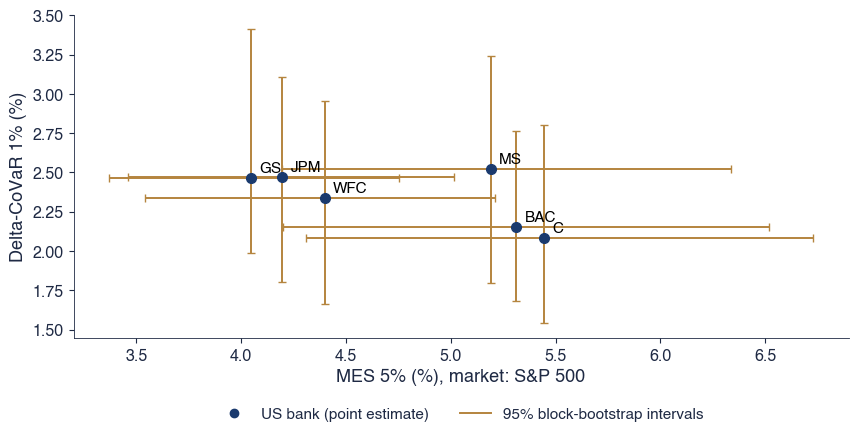

In [14]:
# Solution
def b1_us(save=True):
    """B1: MES 5% against Delta-CoVaR 1% of the six US banks, with 95% block-bootstrap intervals."""
    out, s = region_measures('US')
    fig, ax = plt.subplots(figsize=(10, 4.2))
    for k, v in out.items():
        ax.errorbar(v['mes'], v['dcovar'], xerr=[[v['mes'] - v['mes_lo']], [v['mes_hi'] - v['mes']]],
                    yerr=[[v['dcovar'] - v['ci'][0]], [v['ci'][1] - v['dcovar']]], fmt='o', color=REG_COL['US'],
                    ecolor=st.Amber, capsize=3, ms=7, label='_')
        ax.annotate(k, (v['mes'], v['dcovar']), xytext=(6, 4), textcoords='offset points', fontsize=11, color='black')
    ax.plot([], [], 'o', color=REG_COL['US'], label='US bank (point estimate)')
    ax.plot([], [], color=st.Amber, label='95% block-bootstrap intervals')
    ax.set_xlabel('MES 5% (%), market: S&P 500')
    ax.set_ylabel('Delta-CoVaR 1% (%)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.17)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch15_sem_b1')
    return {'banks': out, **s}


b1 = b1_us(save=False)
print({k: b1[k] for k in ['spearman', 'top_mes', 'top_dcovar']})
pd.DataFrame(b1['banks']).T[['mes', 'mes_lo', 'mes_hi', 'dcovar', 'ci']]

**Interpretation of the result.** No: MES ranks first the banks that fall most with the market (Citigroup, Bank of America), Delta-CoVaR the banks whose distress moves the market most; the intervals overlap.

## B2 [Proposed]: European and Romanian banks

**Question.** Does the disagreement between MES and Delta-CoVaR found in B1 also appear in Europe and in Romania? Model: B1.

1. Compute MES 5% and Delta-CoVaR 1% with bootstrap intervals for each bank, against its own market.
2. Compute the Spearman correlation of the two rankings for the European banks.
3. Compare the two Romanian banks on both measures.
4. Interpretation: is the disagreement between MES and Delta-CoVaR as strong in Europe as in the US?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: US and European banks in 2008

**Question.** Did the link between US and European banks become stronger after Lehman: contagion or interdependence?

1. Compute the correlation of the two portfolios in the calm period (January 2005 – June 2007) and in the crisis (15 September – 31 December 2008).
2. Test the rise in correlation with the one-sided Fisher z test at 5%.
3. Compute $\delta$ from the variance of the US portfolio and the Forbes–Rigobon corrected correlation.
4. Repeat the test with the corrected correlation.
5. Interpretation: contagion or interdependence?

**Report:** six numbers, two decisions, the chart and two sentences.

{'r0': 0.4033614166054101,
 'r1': 0.601471991491272,
 'n0': 506,
 'n1': 72,
 'v0': 0.8903160529749448,
 'v1': 75.38844286247686,
 'delta': 83.67604578236043,
 'radj': 0.08154498638177327,
 'z': 2.0859804024653545,
 'p': 0.018490199150292916,
 'za': -2.694632221605379,
 'pa': 0.996476681884943}

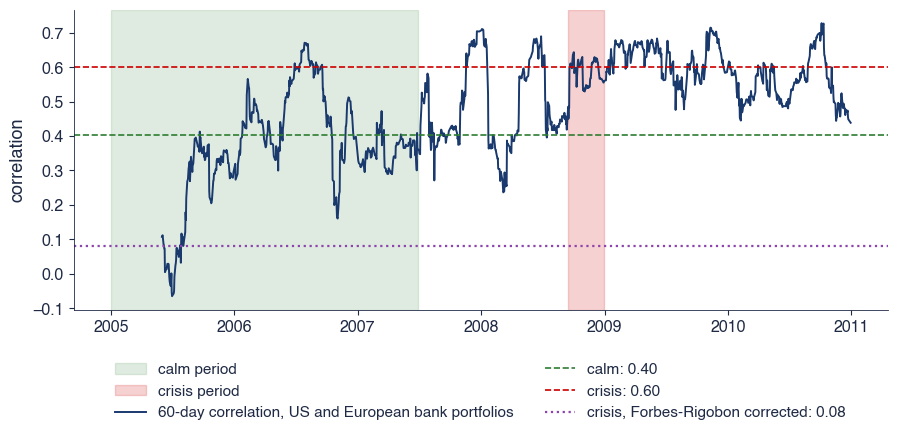

In [16]:
# Solution
def b3_contagion(save=True):
    """B3: US and European bank portfolios, calm January 2005 - June 2007 against 15 September - 31 December 2008."""
    calm, crisis = ('2005-01-01', '2007-06-29'), ('2008-09-15', '2008-12-31')
    c = contagion('US', 'EU', calm, crisis)
    roll = c.pop('roll').loc['2005-06-01':'2010-12-31']
    fig, ax = plt.subplots(figsize=(10.5, 3.9))
    ax.axvspan(pd.Timestamp(calm[0]), pd.Timestamp(calm[1]), color=st.Forest, alpha=0.15, label='calm period')
    ax.axvspan(pd.Timestamp(crisis[0]), pd.Timestamp(crisis[1]), color=st.IDAred, alpha=0.18, label='crisis period')
    ax.plot(roll.index, roll, color=st.MainBlue, lw=1.4, label='60-day correlation, US and European bank portfolios')
    ax.axhline(c['r0'], color=st.Forest, ls='--', lw=1.2, label=f'calm: {c["r0"]:.2f}')
    ax.axhline(c['r1'], color=st.IDAred, ls='--', lw=1.2, label=f'crisis: {c["r1"]:.2f}')
    ax.axhline(c['radj'], color=st.Purple, ls=':', lw=1.6, label=f'crisis, Forbes-Rigobon corrected: {c["radj"]:.2f}')
    ax.set_ylabel('correlation')
    st.legend_outside_bottom(ax, ncol=2, y=-0.13)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch15_sem_b3')
    return c


b3_contagion(save=False)

**Interpretation of the result.** Interdependence: the raw correlation rose significantly, but the variance of the US banks rose about 85 times; after the correction the link is not stronger.

## B4 [Proposed]: European and Romanian banks in 2020

**Question.** Did the link between European and Romanian banks become stronger in the COVID-19 crash? Model: B3.

1. Compute the correlation in the calm period (2019) and in the crisis (20 February – 30 April 2020) and test the rise with the Fisher z test.
2. Compute $\delta$ from the variance of the European portfolio and the corrected correlation.
3. Repeat the test with the corrected correlation.
4. Interpretation: contagion or interdependence?

**Report:** six numbers, two decisions and two sentences.

In [ ]:
# Your code here


## B5 [Solved]: did MES in 2019 rank the losses of March 2020?

**Question.** Do the banks with a high MES before a crisis lose more in it, as in Acharya et al. (2017)?

1. Compute MES 5% of each of the 11 US and European banks in 2019 against its own market.
2. Compute the return of each bank from 19 February to 23 March 2020.
3. Compute the Spearman correlation between MES and the return and its p-value.
4. Interpretation: did MES rank the March 2020 losses?

**Report:** the chart, the correlation with its p-value and two sentences.

{'spearman': -0.5090909090909091, 'p': 0.10973723224165641, 'n': 11, 'worst': 'C', 'top_mes': 'C'}


,region,mes,ret,n_pre
JPM,US,2.253871,-42.519402,241
BAC,US,2.819734,-47.593877,241
C,US,3.168452,-54.657209,241
GS,US,2.663827,-42.782093,241
MS,US,2.943832,-50.612691,241
WFC,US,2.150914,-46.379268,241
DBK,EU,2.881609,-44.395853,242
BNP,EU,2.408327,-52.697532,242
SAN,EU,2.634556,-46.00425,242
INGA,EU,2.648753,-51.77502,242


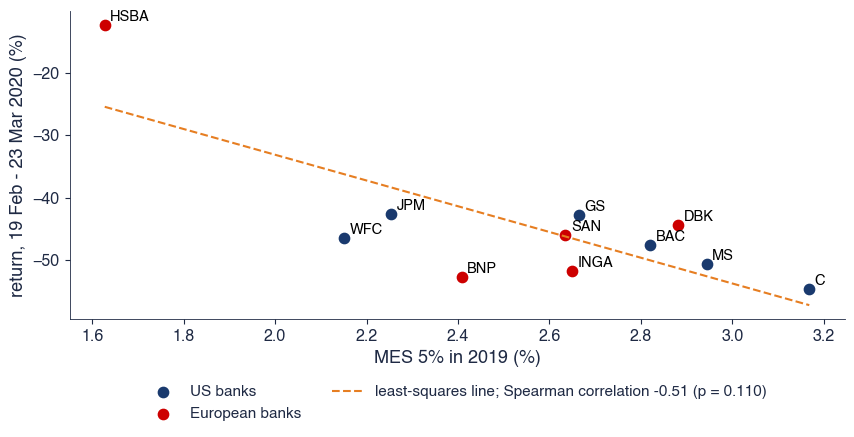

In [18]:
# Solution
def b5_mes2020(save=True):
    """B5: MES 5% in 2019 against the return from 19 February to 23 March 2020 (11 US and European banks)."""
    r = mes_predict(('2019-01-01', '2019-12-31'), ('2020-02-19', '2020-03-23'))
    fig, ax = plt.subplots(figsize=(10, 4.0))
    for reg in ('US', 'EU'):
        ks = [k for k, v in r['banks'].items() if v['region'] == reg]
        ax.scatter([r['banks'][k]['mes'] for k in ks], [r['banks'][k]['ret'] for k in ks], s=55, color=REG_COL[reg],
                   label=REG_LAB[reg])
        for k in ks:
            ax.annotate(k, (r['banks'][k]['mes'], r['banks'][k]['ret']), xytext=(4, 3), textcoords='offset points',
                        fontsize=10.5, color='black')
    x = np.array([v['mes'] for v in r['banks'].values()])
    y = np.array([v['ret'] for v in r['banks'].values()])
    b, a = np.polyfit(x, y, 1)
    g = np.linspace(x.min(), x.max(), 10)
    ax.plot(g, a + b * g, color=st.Orange, ls='--', lw=1.5,
            label=f'least-squares line; Spearman correlation {r["spearman"]:.2f} (p = {r["p"]:.3f})')
    ax.set_xlabel('MES 5% in 2019 (%)')
    ax.set_ylabel('return, 19 Feb - 23 Mar 2020 (%)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.17)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch15_sem_b5')
    return r


b5 = b5_mes2020(save=False)
print({k: b5[k] for k in ['spearman', 'p', 'n', 'worst', 'top_mes']})
pd.DataFrame(b5['banks']).T

**Interpretation of the result.** Partly: the sign is the one of the paper and the extremes match (Citigroup, HSBC), but with 11 banks the correlation is not significant at 5%.

## B6 [Proposed]: did MES in 2022 rank the losses of March 2023?

**Question.** Does the result of B5 hold in the banking turmoil of March 2023? Model: B5.

1. Compute MES 5% of each of the 13 banks in 2022 against its own market.
2. Compute the return of each bank from 28 February to 31 March 2023.
3. Compute the Spearman correlation and its p-value.
4. Interpretation: why may MES fail to rank the losses of March 2023?

**Report:** one table, the correlation with its p-value and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: how connected are Romanian and euro-area banks?

**Question.** What share of the risk of TLV and BRD comes from the European banks, and does it rise in crises? Model: B1 and the connectedness slide.

1. Fit a VAR to the seven return series (order by BIC) and compute the connectedness table for $H = 10$ days.
2. Compute the share of the forecast error variance of TLV and BRD that comes from the five European banks.
3. Repeat it on rolling windows of 250 days and compare 2019 with 2020.
4. Interpretation: is the systemic risk of the Romanian banks imported?

**Report:** a table and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant summarised the systemic risk of JPMorgan Chase. It answered:

- (a) the CoVaR 99% of the S&P 500 given JPM is a negative number;
- (b) Delta-CoVaR = CoVaR minus the VaR of JPM, a negative number, so JPM reduces systemic risk;
- (c) MES 5% is the average loss of the S&P 500 on the worst 5% of days of JPM;
- (d) the bank with the largest VaR 1% is always the most systemic one;
- (e) the correlation of US and European banks rose in autumn 2008, which proves contagion;
- (f) a positive SRISK means that the bank has more capital than it needs in a crisis;
- (g) Granger causality from bank A to bank B means that past returns of A help to forecast B; it does not prove a causal channel.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** seven verdicts with one line of justification each.

In [ ]:
# Your code here
